## Sequential Graph


In [70]:
from typing import TypedDict


# --- 1. STATE ---
# Each field is written by exactly one node downstream
class State(TypedDict):
    current: str  # user provides this
    cleaned: str  # step 1 output
    title_case: str  # step 2 output
    final: str  # step 3 output

In [71]:
# --- 2. NODES ---
def clean_node(state: State) -> dict:
    """Step 1 — Strip whitespace and lowercase"""
    cleaned = state["current"].strip().lower()
    print(f"[clean]      '{state['current']}' → '{cleaned}'")
    return {"cleaned": cleaned, "current": cleaned}


def titlecase_node(state: State) -> dict:
    """Step 2 — Uppercase first letter of each word"""
    title = state["current"].title()
    print(f"[uppercase]  '{state['current']}' → '{title}'")
    return {"title_case": title, "current": title}


def format_node(state: State) -> dict:
    """Step 3 — Wrap in a formatted output string"""
    final = f"✅ Result: [{state['current']}]"
    print(f"[format]     '{state['current']}' → '{final}'")
    return {"final": final, "current": final}

In [78]:
from langgraph.graph import StateGraph, START, END


# --- 3. GRAPH CONSTRUCTION ---
builder = StateGraph(State)

builder.add_node("clean", clean_node)
builder.add_node("titlecase", titlecase_node)
builder.add_node("format", format_node)

# Straight line: each node flows into the next
builder.add_edge(START, "clean")
builder.add_edge("clean", "titlecase")
builder.add_edge("titlecase", "format")
builder.add_edge("format", END)

graph = builder.compile()

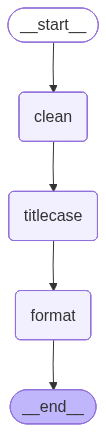

In [79]:
# --- 4. VISUALIZE ---
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [80]:
# --- 5. RUN & TEST ---
inputs = [
    "  hello langgraph!  ",
    "  building ai agents with python  ",
]
for raw in inputs:
    r = graph.invoke(
        {
            "current": raw,
            "cleaned": "",
            "title_case": "",
            "final": "",
        }
    )
    print(f"Output: {r['final']}\n")

[clean]      '  hello langgraph!  ' → 'hello langgraph!'
[uppercase]  'hello langgraph!' → 'Hello Langgraph!'
[format]     'Hello Langgraph!' → '✅ Result: [Hello Langgraph!]'
Output: ✅ Result: [Hello Langgraph!]

[clean]      '  building ai agents with python  ' → 'building ai agents with python'
[uppercase]  'building ai agents with python' → 'Building Ai Agents With Python'
[format]     'Building Ai Agents With Python' → '✅ Result: [Building Ai Agents With Python]'
Output: ✅ Result: [Building Ai Agents With Python]

